# Trip Patterns and Taxi Operations

This notebook explores trip-level and day-level operating patterns in the Chicago taxi data. We use a reproducible 100,000-trip sample to characterize duration, fares, tips, distance, daily activity, and estimated idle time.

## Analysis roadmap

1. Load and validate the cleaned data
2. Describe a representative trip sample
3. Examine distributions of trip-level metrics
4. Aggregate patterns by day
5. Quantify idle time between trips
6. Summarize the operational findings


In [45]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings

# Use a varied, colorblind-friendly palette across the exploratory plots.
plot_palette = sns.color_palette("colorblind", 8)
plt.rcParams["axes.prop_cycle"] = plt.cycler(color=plot_palette)

In [46]:
PARQUET_PATH = '../../data/chicago_taxi_2024_2026_clean.parquet'

print(f'Loading: {PARQUET_PATH}')
df_2025_clean = pd.read_parquet(PARQUET_PATH)
print(f'Loaded {len(df_2025_clean):,} rows and {df_2025_clean.shape[1]} columns.')
df_2025_clean.head(10)

Loading: ../data/chicago_taxi_2024_2026_clean.parquet
Loaded 14,465,662 rows and 27 columns.


,trip_id,taxi_id,trip_start_timestamp,trip_end_timestamp,trip_seconds,trip_miles,pickup_census_tract,dropoff_census_tract,pickup_community_area,dropoff_community_area,...,pickup_centroid_latitude,pickup_centroid_longitude,dropoff_centroid_latitude,dropoff_centroid_longitude,pickup_flag,dropoff_flag,pickup_ca_centroid_lat,pickup_ca_centroid_lon,dropoff_ca_centroid_lat,dropoff_ca_centroid_lon
0,cd9efc3a2f17e7807815b85da5243858aa220972,c53face33b74e90c719c30c33f394050ca1e93ca6b11a8...,2024-01-07 23:45:00,2024-01-08 00:15:00,2530.0,9.200000,NaN,NaN,3,<NA>,...,41.965813,-87.655876,NaN,NaN,1,0,41.965813,-87.655876,NaN,NaN
1,c24cefb09bac1ecb318b96b59b9a424e460ef29e,2e7f98f477c93ec4c458c0f46cad563cc83e813d5ebc0d...,2024-01-07 23:45:00,2024-01-08 00:15:00,1107.0,14.040000,NaN,NaN,76,22,...,41.980263,-87.913628,41.922760,-87.699158,1,1,41.980263,-87.913628,41.922760,-87.699158
2,b6f5e763d27a57350f8f7e42396d9341d887e203,eb7536e0b280d7842bd4448d3fc93ca078630c2f39f122...,2024-01-07 23:45:00,2024-01-08 00:30:00,3295.0,26.559999,NaN,NaN,76,39,...,41.980263,-87.913628,41.808918,-87.596184,1,1,41.980263,-87.913628,41.808918,-87.596184
3,b6af7c1364cc4c8cf4dbb61f746116682d10b768,cefcf124c1b1156a94b0d3c6edd07763849c63f800638f...,2024-01-07 23:45:00,2024-01-08 00:00:00,660.0,0.200000,NaN,NaN,76,76,...,41.980263,-87.913628,41.980263,-87.913628,1,1,41.980263,-87.913628,41.980263,-87.913628
4,aa07462edd535624bc66e0d91d327370af946c90,d5dc4a704805faed89d18144387c3f5f9150df85c6ea5d...,2024-01-07 23:45:00,2024-01-08 00:00:00,1175.0,16.280001,NaN,NaN,76,28,...,41.980263,-87.913628,41.874004,-87.663521,1,1,41.980263,-87.913628,41.874004,-87.663521
5,9f4391e80166a94c4902ceaf554909203f81cefb,11f73b08790612efe341cf8cf69cadbcb7732293794186...,2024-01-07 23:45:00,2024-01-08 00:00:00,900.0,8.600000,NaN,NaN,33,3,...,41.857185,-87.620331,41.965813,-87.655876,1,1,41.857185,-87.620331,41.965813,-87.655876
6,94768c55269efc39b41551fbd7456ad6a84765f2,6dcd43a953f0c1bdfc49fe8260b9504af2cc45eefdfc22...,2024-01-07 23:45:00,2024-01-08 00:15:00,1212.0,17.820000,NaN,NaN,76,8,...,41.980263,-87.913628,41.899601,-87.633308,1,1,41.980263,-87.913628,41.899601,-87.633308
7,04e40c7d73e387e8516d7e69be774e6cf838447e,6dbac74c2838addb28d0bf34cf126cf1624cc61180bfb2...,2024-01-07 23:45:00,2024-01-08 00:15:00,1741.0,18.370001,1.703198e+10,NaN,76,<NA>,...,41.979073,-87.903038,NaN,NaN,1,0,41.980263,-87.913628,NaN,NaN
8,0ebab4b1c5e7f2c7f9989ac407b12be8f85967e0,761789d686c96d6a313aecc3d5080955d5353b3a7f8d89...,2024-01-07 23:45:00,2024-01-08 00:00:00,1409.0,15.510000,NaN,NaN,76,24,...,41.980263,-87.913628,41.901207,-87.676353,1,1,41.980263,-87.913628,41.901207,-87.676353
9,12ce6337235c0cc1c222858a9d96f723b2ac0524,cf278f6c67e799170264672cf78527e136318d96aefd5f...,2024-01-07 23:45:00,2024-01-07 23:45:00,563.0,4.320000,NaN,NaN,76,76,...,41.980263,-87.913628,41.980263,-87.913628,1,1,41.980263,-87.913628,41.980263,-87.913628


## 1. Reproducible analysis sample

The full cleaned dataset is loaded above. To keep exploratory plots responsive, the analysis below uses a fixed random sample of 100,000 trips (seed 42). The sample is used for descriptive exploration, not model fitting.


In [47]:
sample_data_df = df_2025_clean.sample(
    n=100_000,
    random_state=42
)

In [48]:
sample_data_df["trip_start_timestamp"] = pd.to_datetime(
    sample_data_df["trip_start_timestamp"]
)

sample_data_df["trip_end_timestamp"] = pd.to_datetime(
    sample_data_df["trip_end_timestamp"]
)


## 2. Trip-level summary

Before plotting, we calculate a compact set of descriptive metrics covering trip volume, duration, fare, tips, distance, and fare intensity. These values provide context for the distributions that follow.


In [49]:
metrics = {
    "Number of trips": sample_data_df["trip_id"].count(),
    "Average trip duration (seconds)": sample_data_df["trip_seconds"].mean(),
    "Average fare per trip": sample_data_df["trip_total"].mean(),
    "Fare per minute": sample_data_df["trip_total"].sum() / (sample_data_df["trip_seconds"].sum() / 60),
    "Total revenue": sample_data_df["trip_total"].sum(),
    "Tips per trip": sample_data_df["tips"].mean(),
    "Average trip distance (miles)": sample_data_df["trip_miles"].mean()
}

metrics_df = pd.DataFrame(metrics.items(), columns=["metric", "value"])
metrics_df

,metric,value
0,Number of trips,1.000000e+05
1,Average trip duration (seconds),1.259535e+03
2,Average fare per trip,2.697923e+01
3,Fare per minute,1.285199e+00
4,Total revenue,2.697922e+06
5,Tips per trip,2.738332e+00
6,Average trip distance (miles),7.089024e+00


In [50]:
df_plot = sample_data_df.copy()

df_plot["trip_minutes"] = df_plot["trip_seconds"] / 60
df_plot["fare_per_minute"] = df_plot["trip_total"] / df_plot["trip_minutes"]

# Optional: remove invalid / extreme values for cleaner plots
df_plot = df_plot[
    (df_plot["trip_seconds"] > 0) &
    (df_plot["trip_total"] >= 0) &
    (df_plot["tips"] >= 0)
].copy()

df_plot = df_plot.replace([float("inf"), -float("inf")], pd.NA)

In [51]:
# Make sure timestamps are datetime
df_plot["trip_start_timestamp"] = pd.to_datetime(df_plot["trip_start_timestamp"])
df_plot["trip_end_timestamp"] = pd.to_datetime(df_plot["trip_end_timestamp"])

# Sort by taxi and start time so "next trip" is meaningful
df_plot = df_plot.sort_values(["taxi_id", "trip_start_timestamp"]).copy()

# Next trip start for the same taxi
df_plot["next_trip_start"] = (
    df_plot
    .groupby("taxi_id")["trip_start_timestamp"]
    .shift(-1)
)

# Idle time between this trip ending and the next trip starting
df_plot["idle_time_seconds"] = (
    df_plot["next_trip_start"] - df_plot["trip_end_timestamp"]
).dt.total_seconds()

# Optional cleaning: remove impossible negative idle times
df_plot.loc[df_plot["idle_time_seconds"] < 0, "idle_time_seconds"] = pd.NA

df_plot["idle_time_minutes"] = df_plot["idle_time_seconds"] / 60

## 3. Trip-level distributions

The following plots show how trip duration, fare, fare intensity, and tips vary across individual taxi rides. The distributions are exploratory; because extreme values can strongly affect means, medians and quantiles should be preferred for formal comparisons.


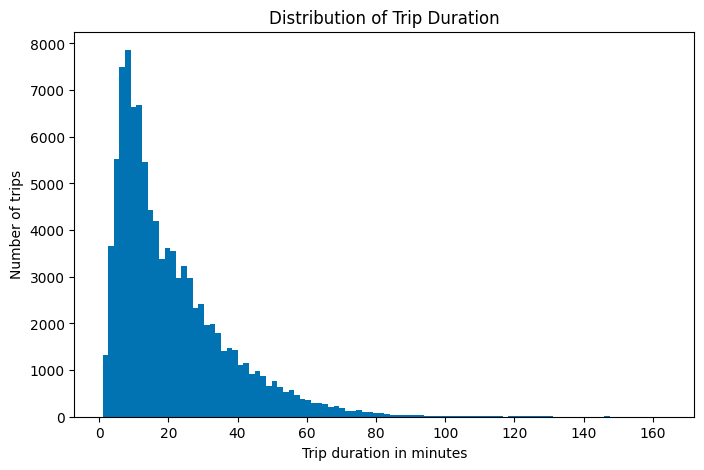

In [52]:
plt.figure(figsize=(8, 5))
plt.hist(df_plot["trip_minutes"].dropna(), bins=100, color=plot_palette[0])
plt.title("Distribution of Trip Duration")
plt.xlabel("Trip duration in minutes")
plt.ylabel("Number of trips")
plt.show()

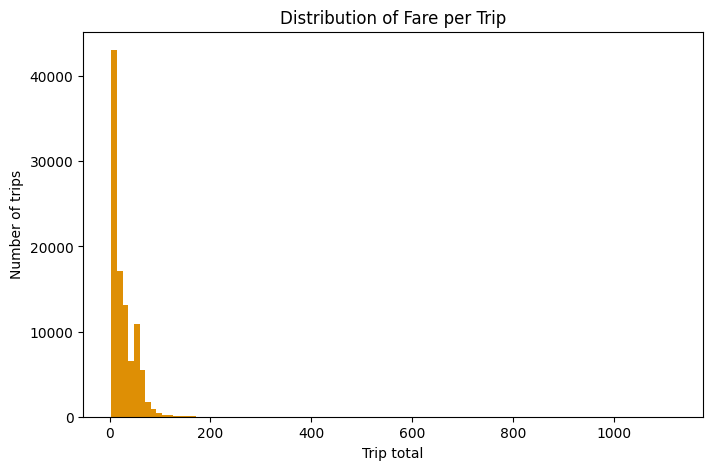

In [53]:
plt.figure(figsize=(8, 5))
plt.hist(df_plot["trip_total"].dropna(), bins=100, color=plot_palette[1])
plt.title("Distribution of Fare per Trip")
plt.xlabel("Trip total")
plt.ylabel("Number of trips")
plt.show()

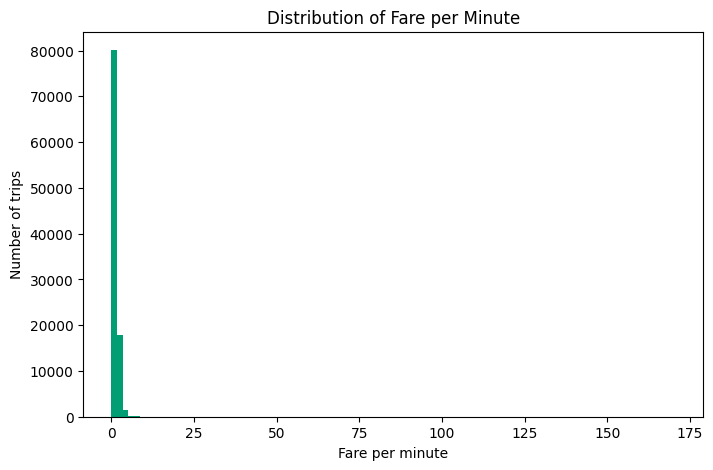

In [54]:
plt.figure(figsize=(8, 5))
plt.hist(df_plot["fare_per_minute"].dropna(), bins=100, color=plot_palette[2])
plt.title("Distribution of Fare per Minute")
plt.xlabel("Fare per minute")
plt.ylabel("Number of trips")
plt.show()

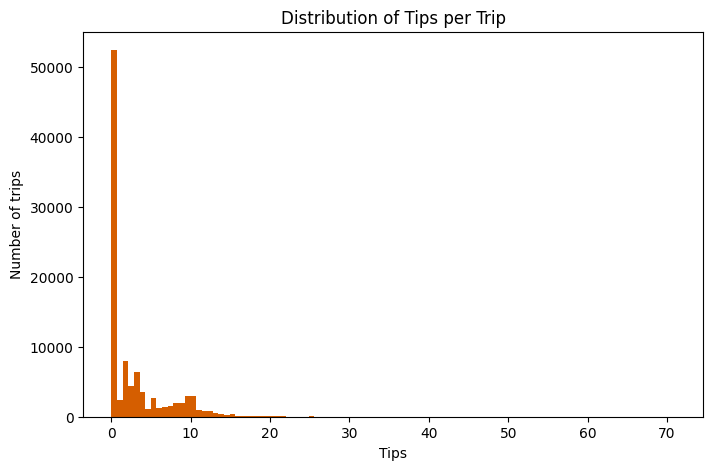

In [55]:
plt.figure(figsize=(8, 5))
plt.hist(df_plot["tips"].dropna(), bins=100, color=plot_palette[3])
plt.title("Distribution of Tips per Trip")
plt.xlabel("Tips")
plt.ylabel("Number of trips")
plt.show()

## 4. Daily operating patterns

Trip records are aggregated by calendar day to assess sample activity, typical trip characteristics, and revenue variability. Because the aggregation uses a random sample rather than the full fleet, the trip counts and revenue totals are sample-based and should not be interpreted as city-wide totals. The daily averages are more useful for comparing day-to-day variation.


In [56]:
df_plot["date"] = df_plot["trip_start_timestamp"].dt.date

daily_metrics = (
    df_plot
    .groupby("date")
    .agg(
        number_of_trips=("trip_id", "count"),
        average_trip_duration_seconds=("trip_seconds", "mean"),
        average_fare_per_trip=("trip_total", "mean"),
        total_revenue=("trip_total", "sum"),
        tips_per_trip=("tips", "mean"),
        total_trip_seconds=("trip_seconds", "sum"),
        average_trip_distance_miles=("trip_miles", "mean")
    )
)

daily_metrics["fare_per_minute"] = (
    daily_metrics["total_revenue"] / (daily_metrics["total_trip_seconds"] / 60)
)

daily_metrics.head()

,number_of_trips,average_trip_duration_seconds,average_fare_per_trip,total_revenue,tips_per_trip,total_trip_seconds,average_trip_distance_miles,fare_per_minute
date,,,,,,,,
2024-01-01,61,1334.032837,35.629017,2173.370117,2.884426,81376.0,9.219016,1.602465
2024-01-02,80,1138.300049,29.499500,2359.959961,2.903750,91064.0,7.852250,1.554924
2024-01-03,71,1005.661987,27.900141,1980.910034,2.921972,71402.0,6.970422,1.664584
2024-01-04,75,1006.733337,24.718933,1853.920044,2.078400,75505.0,6.146266,1.473216
2024-01-05,83,1131.542114,26.760721,2221.139893,2.422530,93918.0,7.208313,1.418987


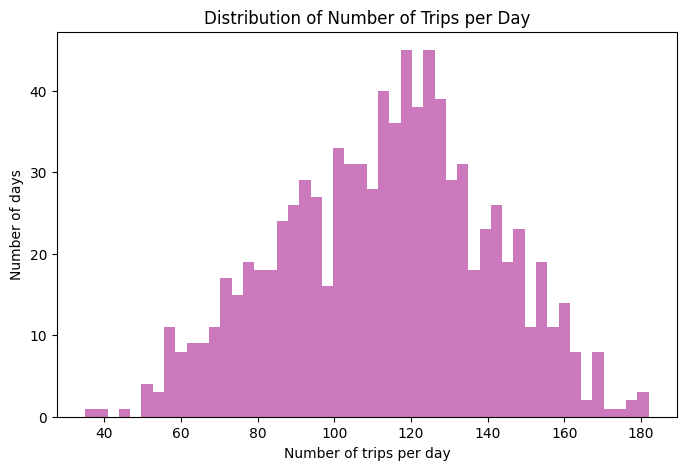

In [57]:
plt.figure(figsize=(8, 5))
plt.hist(daily_metrics["number_of_trips"].dropna(), bins=50, color=plot_palette[4])
plt.title("Distribution of Number of Trips per Day")
plt.xlabel("Number of trips per day")
plt.ylabel("Number of days")
plt.show()

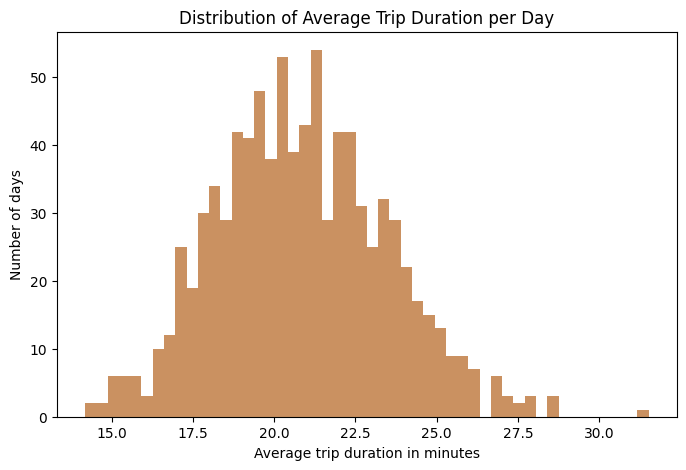

In [58]:
plt.figure(figsize=(8, 5))
plt.hist(daily_metrics["average_trip_duration_seconds"].dropna() / 60, bins=50, color=plot_palette[5])
plt.title("Distribution of Average Trip Duration per Day")
plt.xlabel("Average trip duration in minutes")
plt.ylabel("Number of days")
plt.show()

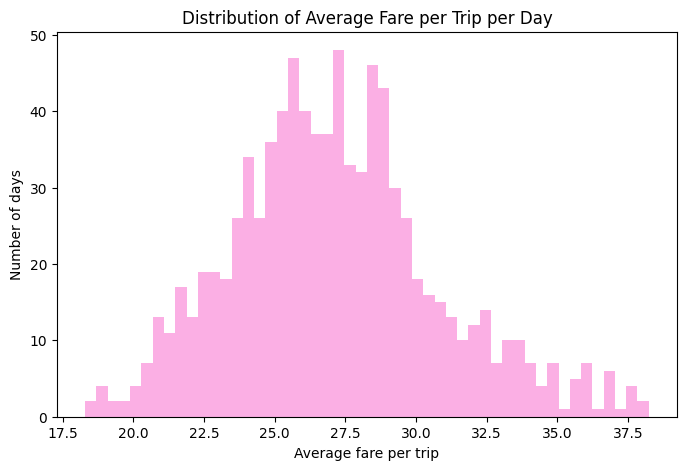

In [59]:
plt.figure(figsize=(8, 5))
plt.hist(daily_metrics["average_fare_per_trip"].dropna(), bins=50, color=plot_palette[6])
plt.title("Distribution of Average Fare per Trip per Day")
plt.xlabel("Average fare per trip")
plt.ylabel("Number of days")
plt.show()

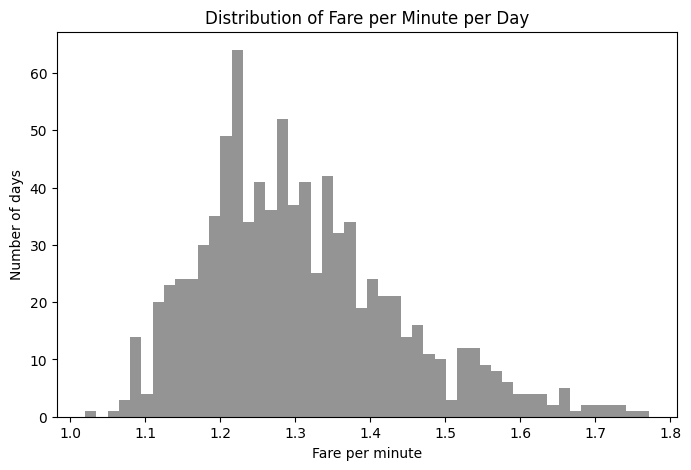

In [60]:
plt.figure(figsize=(8, 5))
plt.hist(daily_metrics["fare_per_minute"].dropna(), bins=50, color=plot_palette[7])
plt.title("Distribution of Fare per Minute per Day")
plt.xlabel("Fare per minute")
plt.ylabel("Number of days")
plt.show()

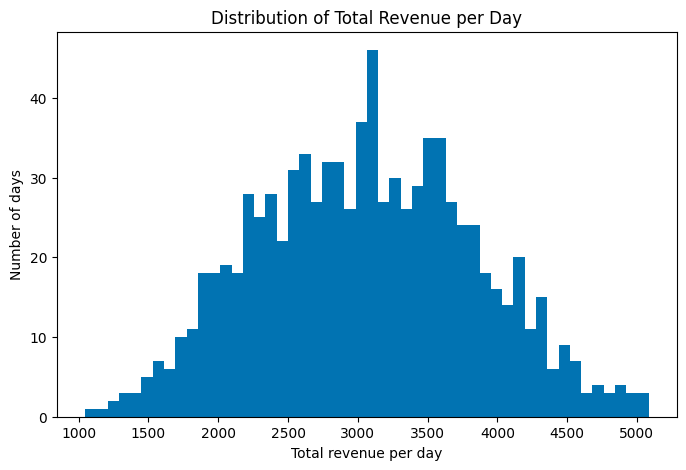

In [61]:
plt.figure(figsize=(8, 5))
plt.hist(daily_metrics["total_revenue"].dropna(), bins=50, color=plot_palette[0])
plt.title("Distribution of Total Revenue per Day")
plt.xlabel("Total revenue per day")
plt.ylabel("Number of days")
plt.show()

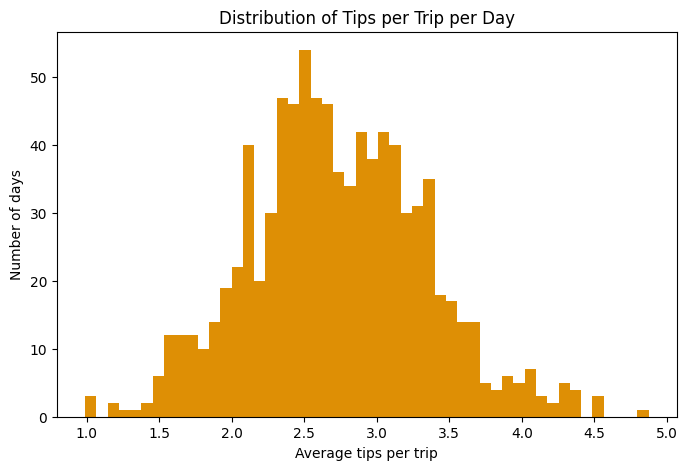

In [62]:
plt.figure(figsize=(8, 5))
plt.hist(daily_metrics["tips_per_trip"].dropna(), bins=50, color=plot_palette[1])
plt.title("Distribution of Tips per Trip per Day")
plt.xlabel("Average tips per trip")
plt.ylabel("Number of days")
plt.show()

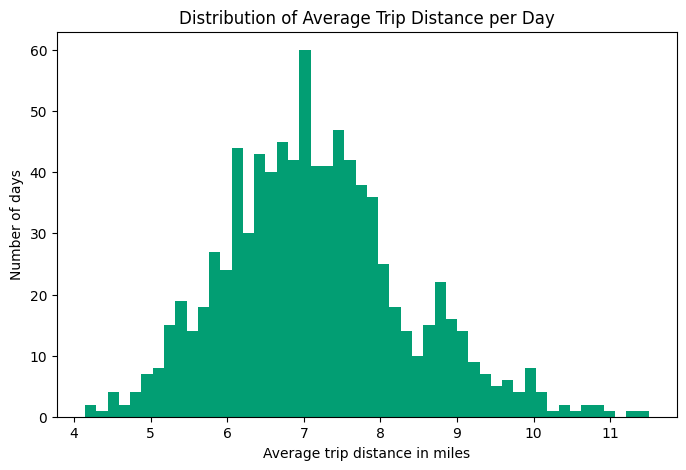

In [63]:
plt.figure(figsize=(8, 5))
plt.hist(daily_metrics["average_trip_distance_miles"].dropna(), bins=50, color=plot_palette[2])
plt.title("Distribution of Average Trip Distance per Day")
plt.xlabel("Average trip distance in miles")
plt.ylabel("Number of days")
plt.show()

## 5. Estimated idle time

Idle time is estimated as the gap between the end of one sampled trip and the start of the next observed sampled trip for the same taxi. This measure is strongly affected by sampling: trips that are not selected create artificially long gaps. It therefore indicates data coverage and possible availability only qualitatively; it is not a reliable estimate of actual vehicle idle time or charging opportunity.


In [64]:
df_idle = sample_data_df.copy()

df_idle["trip_start_timestamp"] = pd.to_datetime(df_idle["trip_start_timestamp"])
df_idle["trip_end_timestamp"] = pd.to_datetime(df_idle["trip_end_timestamp"])

df_idle = df_idle.sort_values(["taxi_id", "trip_start_timestamp"])

df_idle["next_trip_start"] = (
    df_idle
    .groupby("taxi_id")["trip_start_timestamp"]
    .shift(-1)
)

df_idle["idle_time_minutes"] = (
    df_idle["next_trip_start"] - df_idle["trip_end_timestamp"]
).dt.total_seconds() / 60

df_idle.loc[df_idle["idle_time_minutes"] < 0, "idle_time_minutes"] = pd.NA

In [65]:
idle_time_metric = df_idle["idle_time_minutes"].mean()
idle_time_metric

np.float64(32881.405978665345)

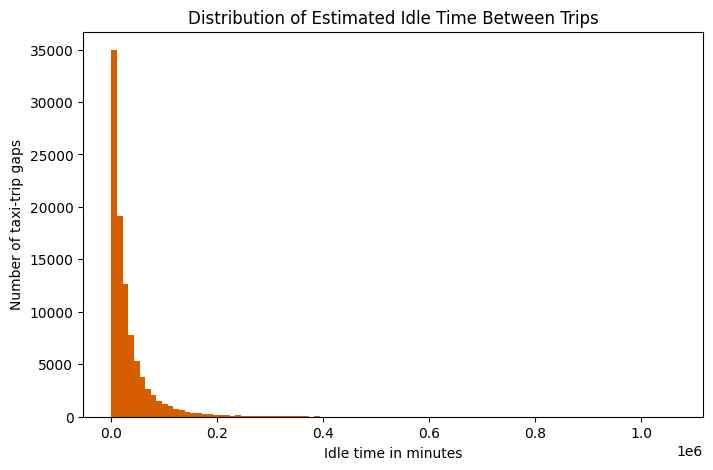

In [66]:
plt.figure(figsize=(8, 5))
plt.hist(df_idle["idle_time_minutes"].dropna(), bins=100, color=plot_palette[3])
plt.title("Distribution of Estimated Idle Time Between Trips")
plt.xlabel("Idle time in minutes")
plt.ylabel("Number of taxi-trip gaps")
plt.show()

## 6. Results and key findings

This exploratory analysis provides three operational takeaways:

- Trip duration, fare, tips, and distance are heterogeneous; medians and quantiles should complement means when reporting these variables.
- Daily sample activity and revenue vary across the observation period. Since the daily aggregation is based on a random sample, these values describe relative variation rather than total city-wide demand or revenue.
- The mean sampled gap between trips is about 32,840 minutes (roughly 22.8 days), demonstrating that the idle-time estimate is dominated by sampling gaps. It must not be used as a direct measure of vehicle utilization or charging availability.

The descriptive patterns motivate the later prediction and reinforcement-learning analyses: demand varies over time and space, while charging decisions must account for operational uncertainty. A reliable utilization or charging analysis would require the full ordered trajectory of each taxi rather than this exploratory sample.
